# RL model comparison
The first cell automatically selects the repository root.

In [1]:
# Make imports work whether VS Code starts in the repository or notebooks folder.
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError(f"Cannot find the project root from {Path.cwd()}")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: C:\Users\jahav\OneDrive\janudrive\project\EV-Charging-RL-Optimizer


In [2]:
import pandas as pd
from src.evaluation.train_and_compare import run_experiment
from src.evaluation.compare_models import compare
from src.utils.config import project_path

# Set True to retrain PPO, DQN and A2C equally inside this notebook.
# This takes several minutes on CPU. False loads and reevaluates saved models.
RUN_TRAINING = False
results = run_experiment(timesteps=10_000, verbose=0) if RUN_TRAINING else compare()

          model  mean_reward  std_reward  success_rate  mean_total_time_minutes  mean_wait_minutes  mean_estimated_cost_inr  mean_utilization_imbalance                                                                 verdict
   Maximum Free    87.497391    1.592438           1.0                49.319554           0.000000               451.318047                    0.242713              Good: reward is at least 75 and meaningfully beats Random.
       Cheapest    87.497391    1.592438           1.0                49.319554           0.000000               451.318047                    0.242713              Good: reward is at least 75 and meaningfully beats Random.
Weighted Greedy    85.995884    1.489607           1.0                45.572717           0.074907               463.726527                    0.303113              Good: reward is at least 75 and meaningfully beats Random.
  Minimum Queue    84.605369    1.690051           1.0                46.791203           0.820699      

,model,mean_reward,std_reward,success_rate,mean_total_time_minutes,mean_wait_minutes,mean_estimated_cost_inr,mean_utilization_imbalance,verdict
0,Maximum Free,87.497,1.592,1.0,49.320,0.000,451.318,0.243,Good: reward is at least 75 and meaningfully b...
1,Cheapest,87.497,1.592,1.0,49.320,0.000,451.318,0.243,Good: reward is at least 75 and meaningfully b...
2,Weighted Greedy,85.996,1.490,1.0,45.573,0.075,463.727,0.303,Good: reward is at least 75 and meaningfully b...
3,Minimum Queue,84.605,1.690,1.0,46.791,0.821,472.580,0.324,Good: reward is at least 75 and meaningfully b...
4,Nearest,84.292,1.558,1.0,47.093,1.197,474.670,0.327,Good: reward is at least 75 and meaningfully b...
5,DQN,82.741,1.418,1.0,53.495,2.584,475.936,0.330,Good: reward is at least 75 and meaningfully b...
6,PPO,82.741,1.418,1.0,53.495,2.584,475.936,0.330,Good: reward is at least 75 and meaningfully b...
7,Random,78.115,2.004,1.0,76.717,7.003,486.368,0.354,"Acceptable: strong absolute reward, but no cle..."
8,A2C,73.541,2.742,1.0,85.974,10.103,501.647,0.352,Needs improvement: mean reward is below 75.


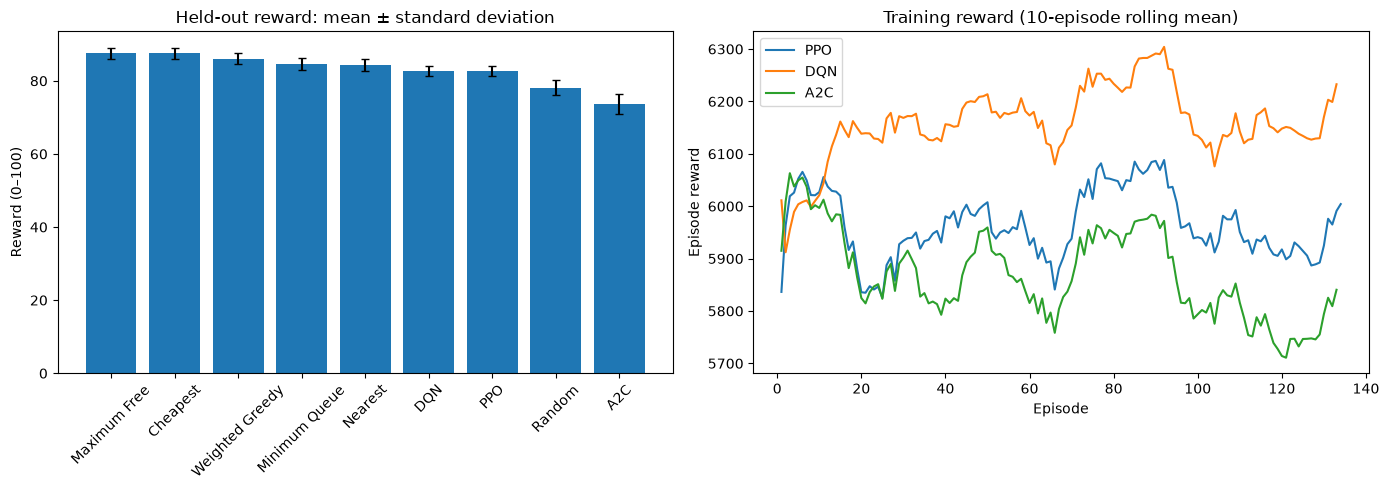

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from src.utils.config import project_path

columns = ['model', 'mean_reward', 'std_reward', 'success_rate',
           'mean_total_time_minutes', 'mean_wait_minutes',
           'mean_estimated_cost_inr', 'mean_utilization_imbalance', 'verdict']
display(results[columns].round(3))

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(results.model, results.mean_reward, yerr=results.std_reward, capsize=3)
axes[0].set_title('Held-out reward: mean ± standard deviation')
axes[0].set_ylabel('Reward (0–100)')
axes[0].tick_params(axis='x', rotation=45)
for algorithm in ('ppo', 'dqn', 'a2c'):
    curve_path = project_path(f'results/metrics/{algorithm}_training_curve.csv')
    curve = pd.read_csv(curve_path)
    axes[1].plot(curve.episode, curve.episode_reward.rolling(10, min_periods=1).mean(), label=algorithm.upper())
axes[1].set_title('Training reward (10-episode rolling mean)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Episode reward')
axes[1].legend()
figure.tight_layout()
plt.show()